# 数据集预处理
针对单个数据集进行严格的：
- 设置随机种子
- 样本筛选
- 细胞质控
- 去除环境污染（是否需要？）
- 保存质控后数据至'UC/scRNA-seq_data/03_qc_filtered'文件夹
- 批次效应查看
- 降维聚类结果
- 处理异常细胞群
- 区分主要谱系

# 文件说明
- **文件名**: 3_GSE150115_qc.h5ad 
- **存放位置**: 坚果云  `UC/scRNA-seq_data/03_qc_filtered/`  
- **生成日期**: 2025-11-3  
- **生成者**: Jiang Lai
- **对应脚本**: notebooks/1_preprocessing/1.2_qc_filtered/3_GSE150115.ipynb  
- **内容说明**: 完成了针对单个数据的预处理工作，包括样本排除、细胞质控，并查看了样本间的批次效应。  

In [1]:
import numpy as np
import random
np.random.seed(42)
random.seed(42)

In [2]:
import scanpy as sc
#sc.settings.verbosity = 1
print(sc.__version__)

/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


1.11.4


## 读取数据
GSE150115数据集：
- 结肠组织细胞
- 3UC

In [3]:
adata = sc.read_h5ad('/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/02_sample_merge/3_GSE150115.h5ad')

In [4]:
adata

AnnData object with n_obs × n_vars = 7244 × 14605
    obs: 'n_genes', 'GSM_id', 'GSM', 'id', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'n_cells'
    uns: 'REFERENCE_MANU', 'scrublet', 'status', 'status_args'

In [5]:
adata.obs.head()

,n_genes,GSM_id,GSM,id,nUMIs,mito_perc,detected_genes,cell_complexity,passing_mt,passing_nUMIs,passing_ngenes,doublet_score,predicted_doublet
GSM4523789_UC8_ACATCCCGTATC,5373,GSM4523789_UC8,GSM4523789,UC8,23639,0.0,5373,0.227294,True,True,True,0.064935,False
GSM4523789_UC8_CGTCCCAATTCA,5766,GSM4523789_UC8,GSM4523789,UC8,24556,0.0,5766,0.234810,True,True,True,0.060507,False
GSM4523789_UC8_CCCATGGAACGA,4097,GSM4523789_UC8,GSM4523789,UC8,17153,0.0,4097,0.238850,True,True,True,0.044920,False
GSM4523789_UC8_GCCGAACCTCTC,4807,GSM4523789_UC8,GSM4523789,UC8,17935,0.0,4807,0.268023,True,True,True,0.031115,False
GSM4523789_UC8_GCCAAGAGGTCA,3405,GSM4523789_UC8,GSM4523789,UC8,12326,0.0,3405,0.276245,True,True,True,0.038443,False


## 处理细胞标签及分组

In [6]:
# 提取分组信息
import pandas as pd
adata.obs['group'] = adata.obs['id'].str.extract(r'([A-Za-z]+)', expand=False)
print(adata.obs[['id', 'group']].head())

                              id group
GSM4523789_UC8_ACATCCCGTATC  UC8    UC
GSM4523789_UC8_CGTCCCAATTCA  UC8    UC
GSM4523789_UC8_CCCATGGAACGA  UC8    UC
GSM4523789_UC8_GCCGAACCTCTC  UC8    UC
GSM4523789_UC8_GCCAAGAGGTCA  UC8    UC


`.obs`当中只保留GSM信息和分组信息

In [7]:
adata.obs.drop(columns=['GSM_id', 'id'], inplace=True)
print(adata.obs.head())

                             n_genes         GSM  nUMIs  mito_perc  \
GSM4523789_UC8_ACATCCCGTATC     5373  GSM4523789  23639        0.0   
GSM4523789_UC8_CGTCCCAATTCA     5766  GSM4523789  24556        0.0   
GSM4523789_UC8_CCCATGGAACGA     4097  GSM4523789  17153        0.0   
GSM4523789_UC8_GCCGAACCTCTC     4807  GSM4523789  17935        0.0   
GSM4523789_UC8_GCCAAGAGGTCA     3405  GSM4523789  12326        0.0   

                             detected_genes  cell_complexity  passing_mt  \
GSM4523789_UC8_ACATCCCGTATC            5373         0.227294        True   
GSM4523789_UC8_CGTCCCAATTCA            5766         0.234810        True   
GSM4523789_UC8_CCCATGGAACGA            4097         0.238850        True   
GSM4523789_UC8_GCCGAACCTCTC            4807         0.268023        True   
GSM4523789_UC8_GCCAAGAGGTCA            3405         0.276245        True   

                             passing_nUMIs  passing_ngenes  doublet_score  \
GSM4523789_UC8_ACATCCCGTATC           True   

In [8]:
adata.obs['group'].value_counts()

group
UC    7244
Name: count, dtype: int64

## 样本质量查看

In [9]:
adata.obs['GSM'].value_counts()

GSM
GSM4523789    3575
GSM4523791    2709
GSM4523790     960
Name: count, dtype: int64

In [10]:
sample_quality_stats = adata.obs.groupby('GSM')[['n_genes', 'nUMIs', 'mito_perc']].agg(['mean', 'std', 'min', 'max'])

print(sample_quality_stats)

                n_genes                               nUMIs                    \
                   mean         std  min   max         mean          std  min   
GSM                                                                             
GSM4523789  1035.585734  710.136000  251  5766  2397.824056  2128.227979  502   
GSM4523790   883.362500  957.786054  251  7664  2425.858333  3618.616341  502   
GSM4523791   949.647841  607.483269  251  5698  2005.704688  1879.004572  502   

                      mito_perc                           
              max          mean       std  min       max  
GSM                                                       
GSM4523789  24556  4.370233e-06  0.000056  0.0  0.001383  
GSM4523790  42452  9.424133e-07  0.000012  0.0  0.000226  
GSM4523791  25776  8.257500e-06  0.000086  0.0  0.001773  


/tmp/ipykernel_9066/2761774101.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_quality_stats = adata.obs.groupby('GSM')[['n_genes', 'nUMIs', 'mito_perc']].agg(['mean', 'std', 'min', 'max'])


## 细胞质控

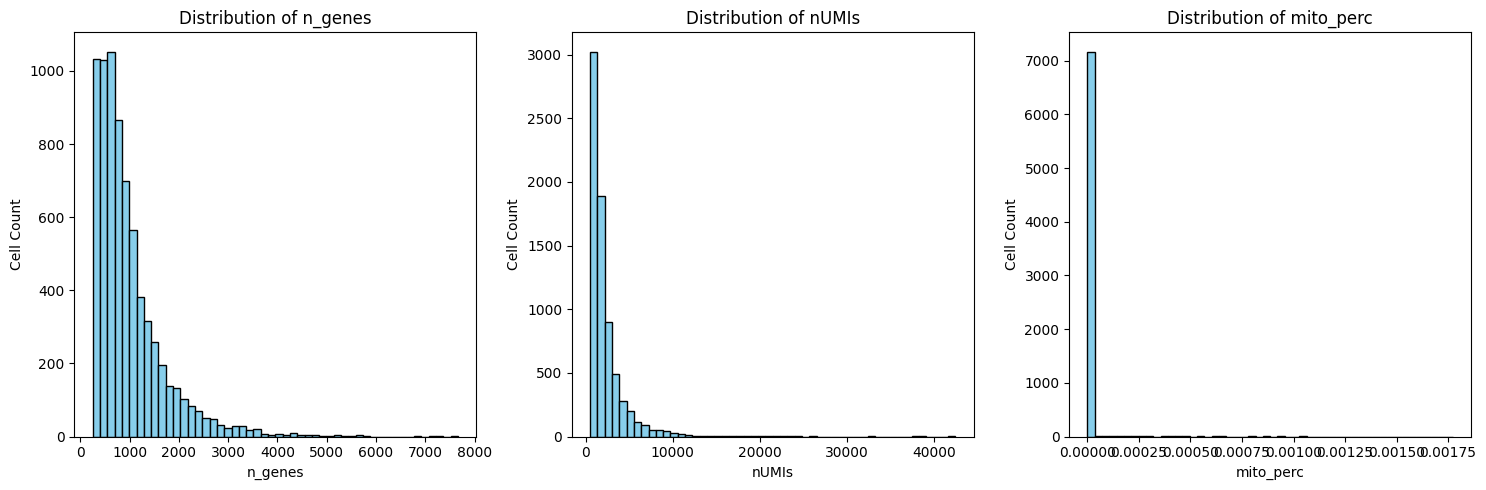

In [11]:
import matplotlib.pyplot as plt

# 选择要可视化的质量控制指标
qc_metrics = ['n_genes', 'nUMIs', 'mito_perc']

# 绘制各个指标的直方图
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# 绘制每个质量控制指标的直方图
for i, metric in enumerate(qc_metrics):
    ax[i].hist(adata.obs[metric], bins=50, color='skyblue', edgecolor='black')
    ax[i].set_title(f'Distribution of {metric}')
    ax[i].set_xlabel(metric)
    ax[i].set_ylabel('Cell Count')

# 调整布局，避免重叠
plt.tight_layout()
plt.show()


/tmp/ipykernel_9066/2077234365.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(labels, rotation=45, ha='right')
/tmp/ipykernel_9066/2077234365.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(labels, rotation=45, ha='right')
/tmp/ipykernel_9066/2077234365.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(labels, rotation=45, ha='right')


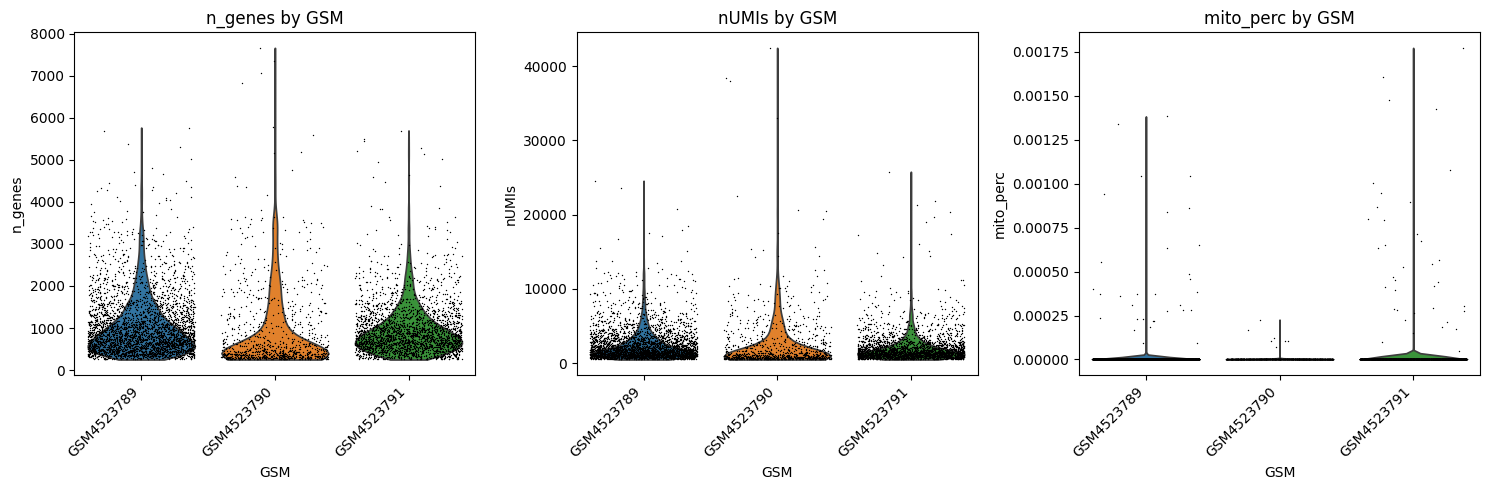

In [12]:
# 设置绘图风格
sc.settings.verbosity = 0  # 简化日志输出

# 选择要绘制的小提琴图的质量控制指标
qc_metrics = ['n_genes', 'nUMIs', 'mito_perc']

# 按照样本（GSM）绘制小提琴图
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

for i, metric in enumerate(qc_metrics):
    sc.pl.violin(adata, keys=metric, groupby='GSM', ax=ax[i], stripplot=True, jitter=0.4, show=False)
    ax[i].set_title(f'{metric} by GSM')
    ax[i].set_ylabel(f'{metric}')
    
    # 获取当前的x轴标签
    labels = ax[i].get_xticklabels()
    # 旋转标签并调整对齐方式（末尾对齐）
    ax[i].set_xticklabels(labels, rotation=45, ha='right')

# 调整布局，避免重叠
plt.tight_layout()
plt.show()


### 严格细胞质控标准
- min_genes = 200          # 最少基因数
- max_genes = 4000         # 最多基因数
- min_umis = 500           # 最少UMI数量
- max_umis = 20000         # 最多UMI数量
- max_mito_perc = 10       # 线粒体基因百分比最大值

In [13]:
# 设置阈值
min_genes = 200          # 最少基因数
max_genes = 6000         # 最多基因数
min_umis = 500           # 最少UMI数量
max_umis = 20000        # 最多UMI数量
max_mito_perc = 0.1       # 线粒体基因百分比最大值

# 根据阈值进行过滤
adata = adata[(adata.obs['n_genes'] > min_genes) & 
              (adata.obs['n_genes'] < max_genes) &
              (adata.obs['nUMIs'] > min_umis) &
              (adata.obs['nUMIs'] < max_umis) &
              (adata.obs['mito_perc'] < max_mito_perc), :]

# 输出过滤后的细胞数
print(f'Number of cells after filtering: {adata.n_obs}')

Number of cells after filtering: 7230


## 保存质控后数据


In [14]:
import os
output_dir = "/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/03_qc_filtered/"
os.makedirs(output_dir, exist_ok=True)
adata.write_h5ad(os.path.join(output_dir, "3_GSE150115_qc.h5ad"), compression='gzip')

## 降维聚类

In [15]:
import omicverse as ov
ov.plot_set(dpi=50)
ov.settings.verbose = 1 
ov.settings.cpu_gpu_mixed_init()

🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
✅ [GPU 0] NVIDIA GeForce RTX 5060 Ti
    • Total memory: 15.9 GB
    • Compute capability: 12.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.7   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

CPU-GPU mixed mode activated


结肠组织细胞，所以选取2000个高变基因  
大致分别谱系，所以选取resolution=0.4

In [16]:
# HVG
adata=ov.pp.preprocess(adata,
                       mode='shiftlog|pearson',
                       n_HVGs=2000,
                       target_sum=50*1e4)

adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]

# PCA
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

# Embedding the neighborhood graph
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='scaled|original|X_pca')

# UMAP
ov.pp.umap(adata)

# Clustering
ov.pp.leiden(adata,resolution=0.4)

Begin robust gene identification
After filtration, 14605/14605 genes are kept.     Among 14605 genes, 14605 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell
The following highly-expressed genes are not considered during normalization factor computation:
['IGHA1', 'IGHG1', 'IGHG2', 'IGHG3', 'IGHG4', 'IGHM', 'IGJ', 'IGKC', 'MALAT1', 'MT-RNR1', 'MT-RNR2']
    finished (0:00:00)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector (adata.var)
Time to analyze data in cpu: 6.3891761302948 seconds.
End of size normalization: shiftlog and HVGs selection pearson
🚀 Using GPU to c

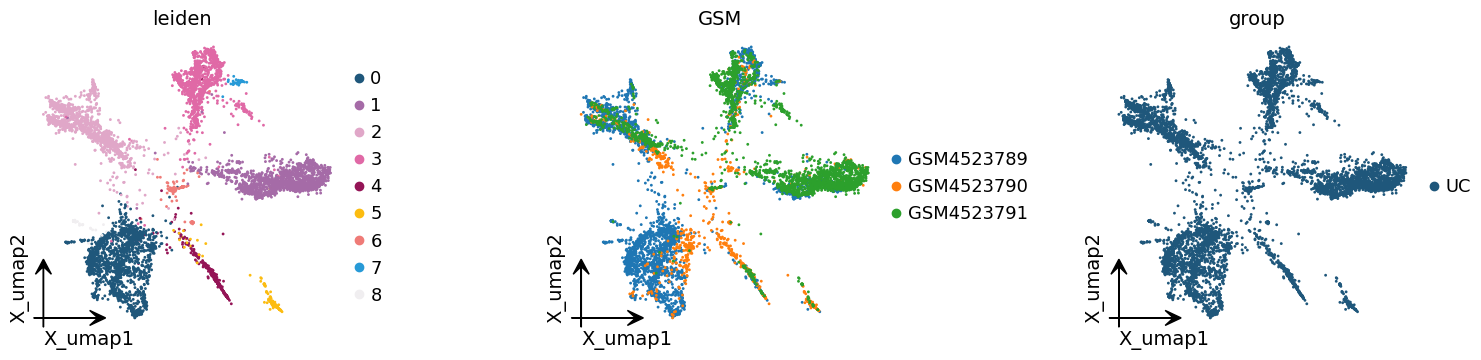

In [17]:
# 可视化查看聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'GSM', 'group'],
                frameon='small',
                wspace=0.5)

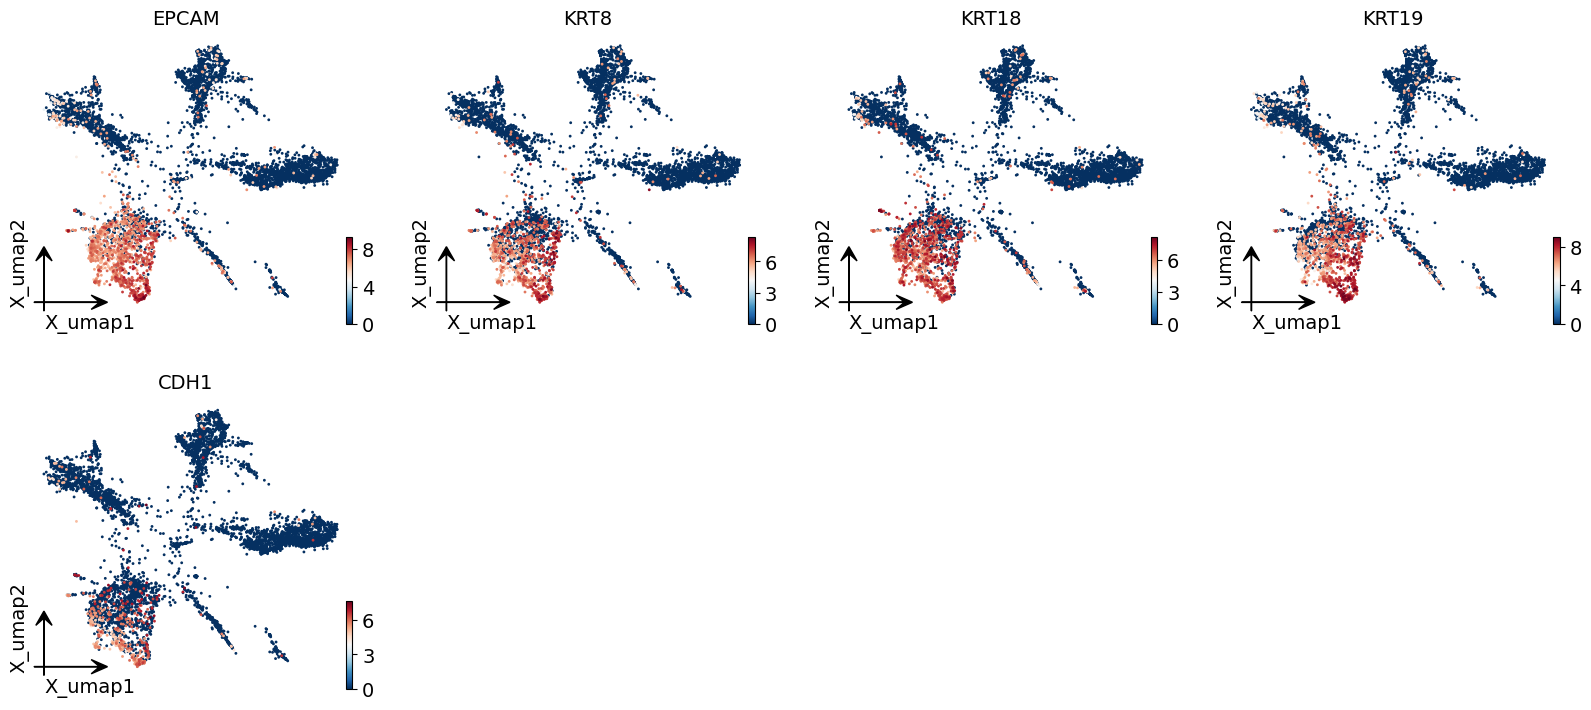

In [20]:
# 上皮谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['EPCAM', 'KRT8', 'KRT18', 'KRT19', 'CDH1'], # CLDN1
                frameon='small')

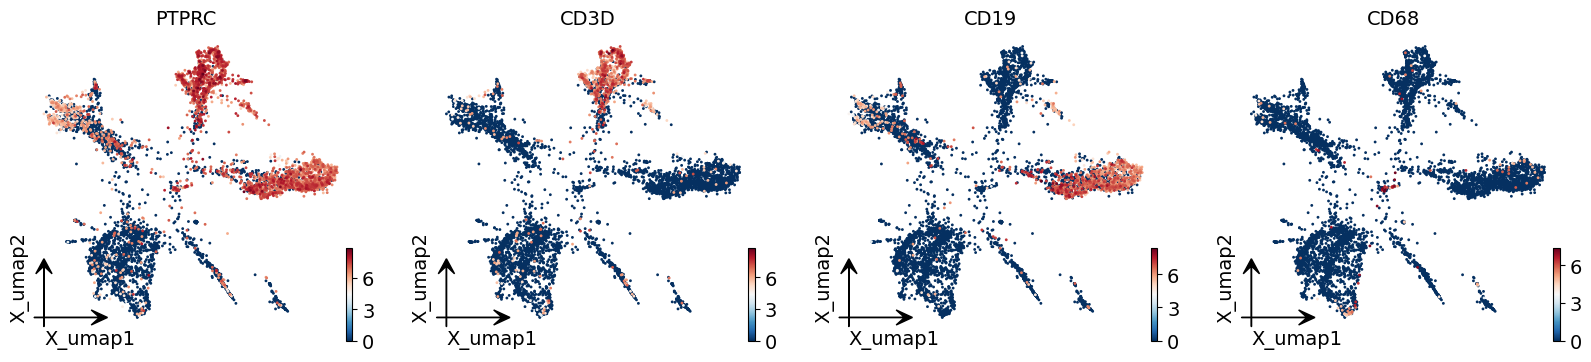

In [21]:
# 免疫谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['PTPRC', 'CD3D', 'CD19', 'CD68'], 
                frameon='small')

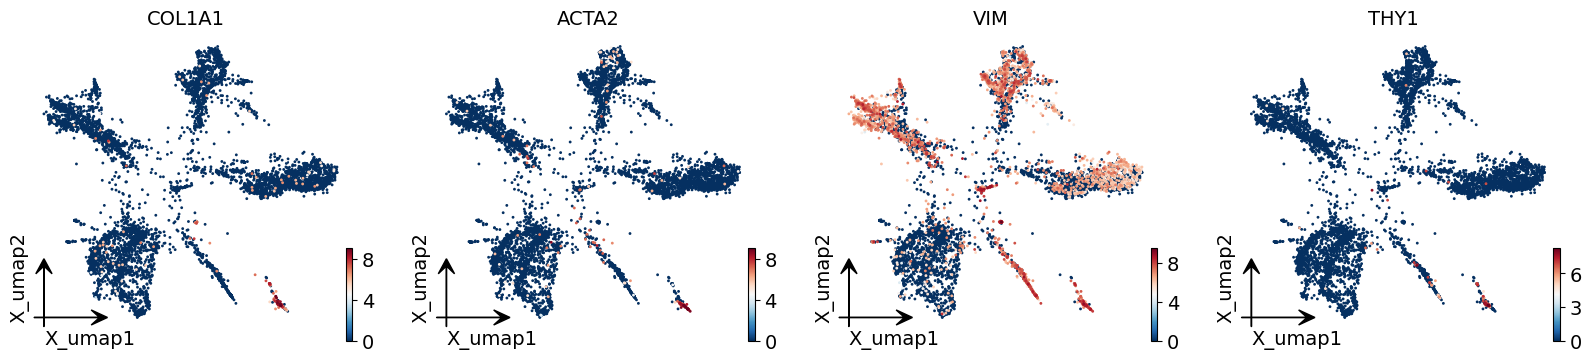

In [22]:
# 基质谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['COL1A1', 'ACTA2', 'VIM', 'THY1'],  # 'FAP'
                frameon='small')

## 去除批次效应
按样本去除批次，看看是否效果会更好

使用`harmony`

In [23]:
ov.single.batch_correction(adata,
                           batch_key='GSM', # 去批次分组标签
                           methods='harmony',
                           n_pcs=50)
                           
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='X_harmony')

ov.pp.umap(adata)

ov.pp.leiden(adata,resolution=0.4)

...Begin using harmony to correct batch effect


2025-11-04 13:00:21,885 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-11-04 13:00:23,345 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-11-04 13:00:23,384 - harmonypy - INFO - Iteration 1 of 10
2025-11-04 13:00:24,284 - harmonypy - INFO - Iteration 2 of 10
2025-11-04 13:00:25,194 - harmonypy - INFO - Iteration 3 of 10
2025-11-04 13:00:26,064 - harmonypy - INFO - Iteration 4 of 10
2025-11-04 13:00:27,046 - harmonypy - INFO - Iteration 5 of 10
2025-11-04 13:00:27,918 - harmonypy - INFO - Converged after 5 iterations


🖥️ Using Scanpy CPU to calculate neighbors...
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
🔍 [2025-11-04 13:00:28] Running UMAP in 'cpu-gpu-mixed' mode...
🚀 Using torch GPU to calculate UMAP...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA GeForce RTX 5060 Ti
    |||--------------------------- 2143/16311 MiB (13.1%)
computing UMAP🚀
    finished ✅: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:04)
✅ UMAP completed successfully.
🖥️ Using Scanpy CPU Leiden...
running Leiden clustering
    finished: found 8 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:01)


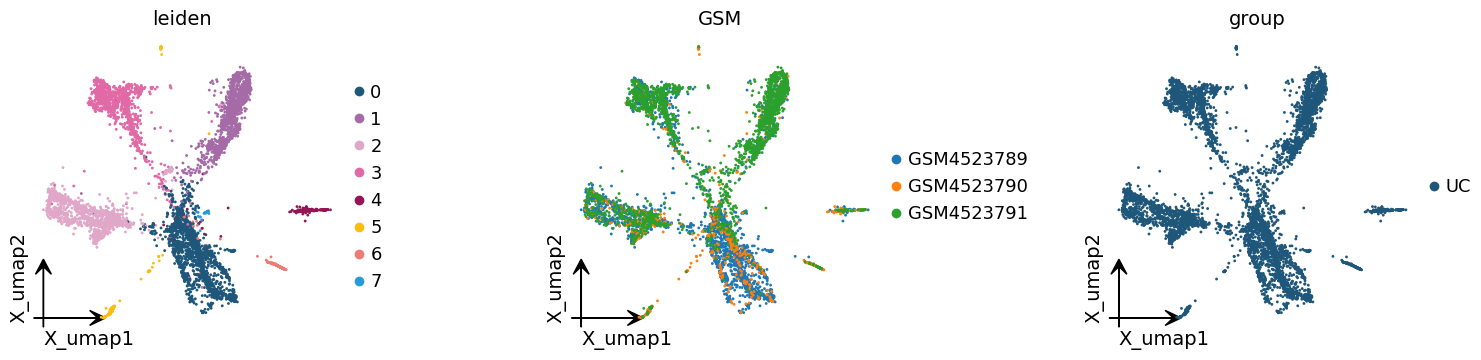

In [24]:
# 可视化查看去除批次效应后聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'GSM', 'group'],
                frameon='small',
                wspace=0.5)

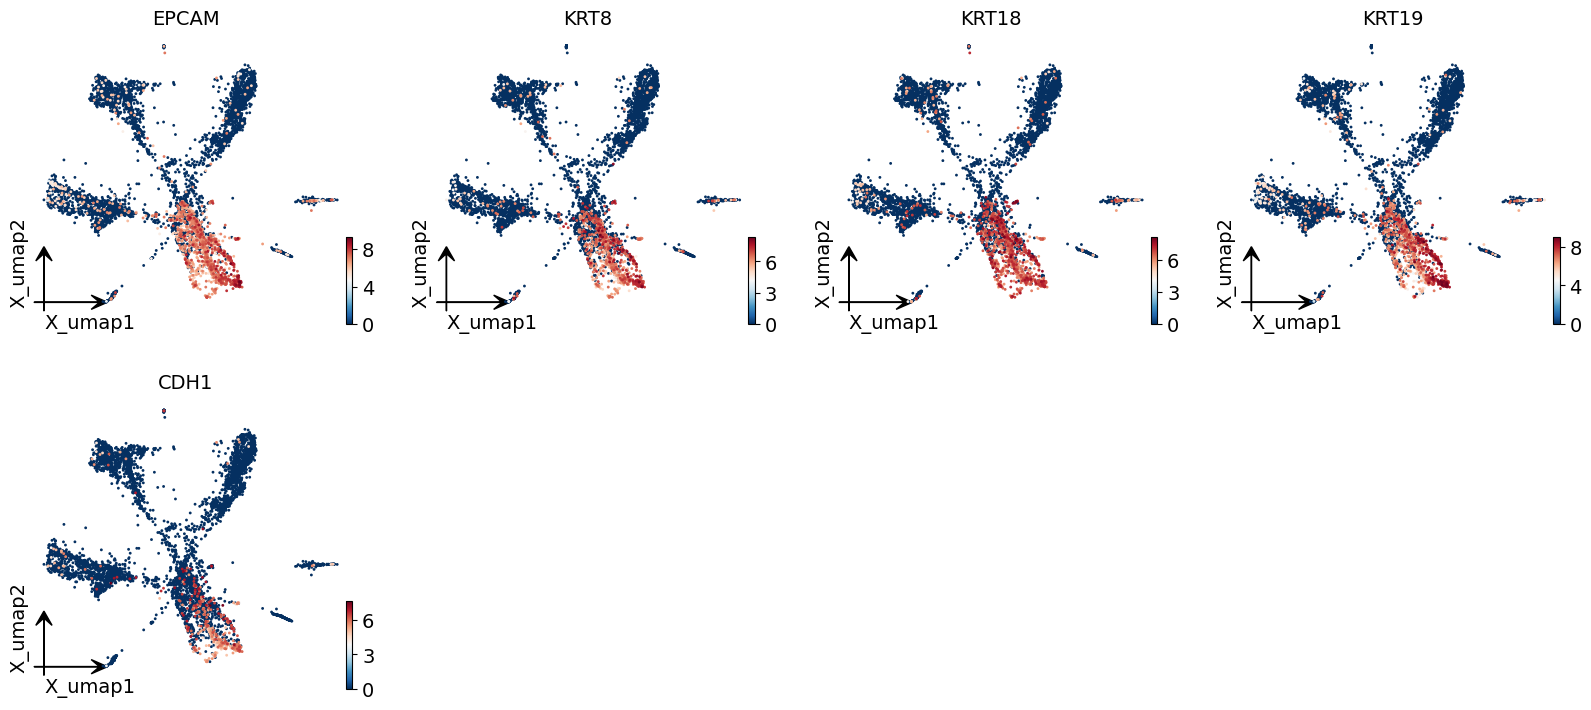

In [25]:
# 上皮谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['EPCAM', 'KRT8', 'KRT18', 'KRT19', 'CDH1'], # CLDN1
                frameon='small')

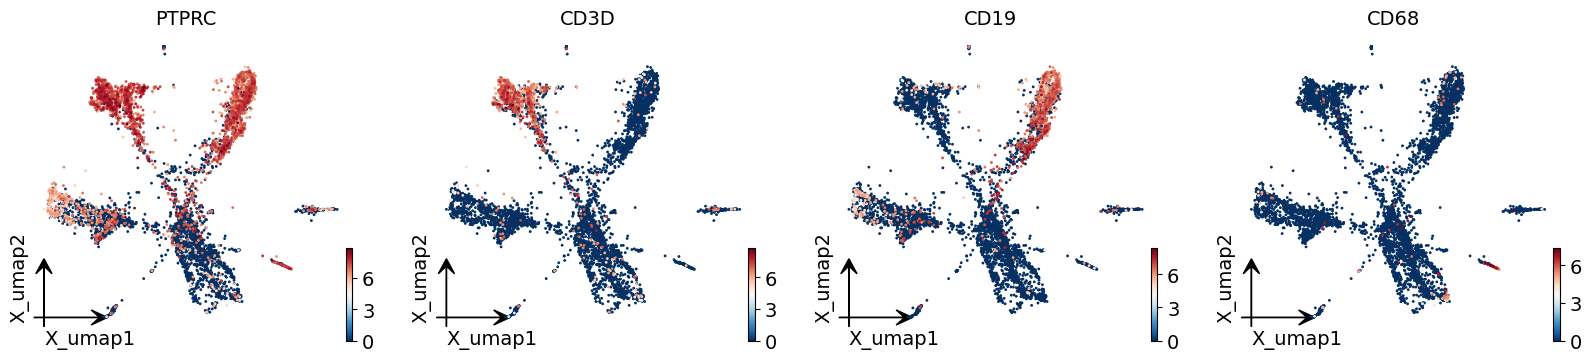

In [26]:
# 免疫谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['PTPRC', 'CD3D', 'CD19', 'CD68'], 
                frameon='small')

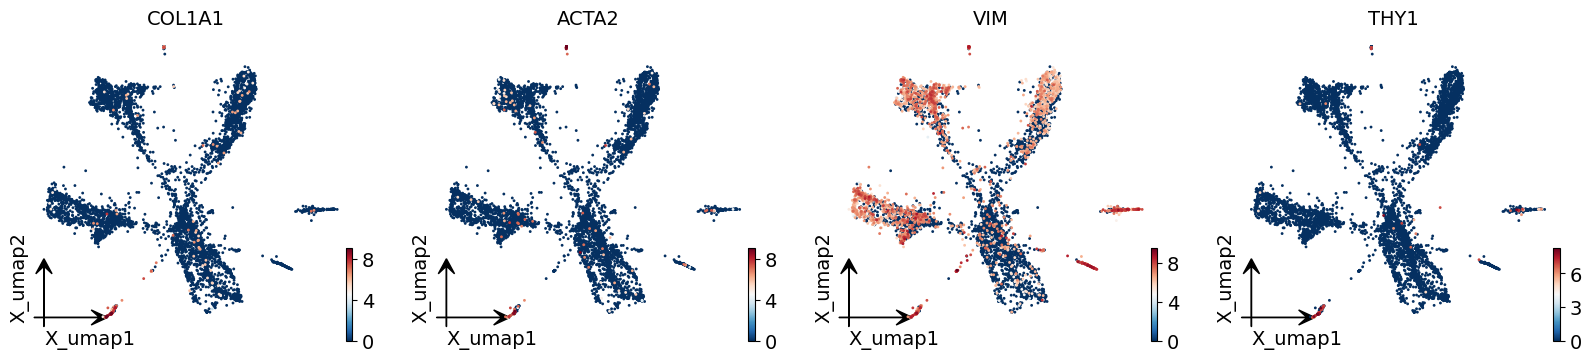

In [27]:
# 基质谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['COL1A1', 'ACTA2', 'VIM', 'THY1'],  # 'FAP'
                frameon='small')

## GPT自动注释

In [28]:
# 获取每个细胞群的基因
all_markers = ov.single.get_celltype_marker(adata,
                                            clustertype='leiden',
                                            rank=True,
                                            key='rank_genes_groups',
                                            foldchange=1,
                                            topgenenumber=10)
all_markers

...get cell type marker
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:03)


{'0': ['EPCAM',
  'MT-ATP6',
  'MT-CO3',
  'LCN2',
  'MT-ND4',
  'PIGR',
  'MT-ND1',
  'MT-CO2',
  'MT-ND2',
  'MT-CYB'],
 '1': ['LAPTM5',
  'BANK1',
  'CXCR4',
  'MS4A1',
  'CD83',
  'HLA-DPA1',
  'HLA-DPB1',
  'HLA-DRA',
  'CD74',
  'HLA-DRB1'],
 '2': ['MZB1',
  'XBP1',
  'IGJ',
  'HSP90B1',
  'DERL3',
  'IGHA1',
  'SSR4',
  'IGKC',
  'SLAMF7',
  'HERPUD1'],
 '3': ['SRGN',
  'TRBC2',
  'SPOCK2',
  'TNFAIP3',
  'CD3D',
  'IL7R',
  'CD2',
  'FYB',
  'PTPRC',
  'ETS1'],
 '4': ['ENG',
  'COL4A2',
  'HSPG2',
  'VWF',
  'A2M',
  'PLVAP',
  'SPARC',
  'IGFBP7',
  'SPARCL1',
  'COL4A1'],
 '5': ['COL4A2',
  'A2M',
  'SPARC',
  'CALD1',
  'IGFBP7',
  'COL1A2',
  'COL3A1',
  'COL6A2',
  'MAP1B',
  'COL4A1'],
 '6': ['LYZ',
  'S100A9',
  'IL1B',
  'SRGN',
  'FTH1',
  'SAT1',
  'IFI30',
  'TYROBP',
  'SOD2',
  'FTL'],
 '7': ['LRMP',
  'TPM1',
  'ALOX5',
  'IL17RB',
  'TP53I3',
  'RASSF6',
  'PTPN18',
  'MALAT1',
  'MATK',
  'BMX']}

In [29]:
os.environ['AGI_API_KEY'] = 'sk-ff0dc715f640466393e6aa71c9da6848'
result = ov.single.gptcelltype(all_markers,
                               tissuename='colon',
                               speciename='human',
                               model='qwen-plus',
                               provider='qwen',
                               topgenenumber=10)
result

Note: AGI API key found: returning the cell type annotations.
Note: It is always recommended to check the results returned by GPT-4 in case of AI hallucination, before going to downstream analysis.


{'0': 'Epithelial cells',
 '1': 'B cells',
 '2': 'Plasma cells',
 '3': 'T cells',
 '4': 'Endothelial cells',
 '5': 'Fibroblasts',
 '6': 'Myeloid cells',
 '7': 'Mast cells'}

In [30]:
# 添加识别结果到obs
adata.obs['gpt_celltype'] = adata.obs['leiden'].map(result).astype('category')

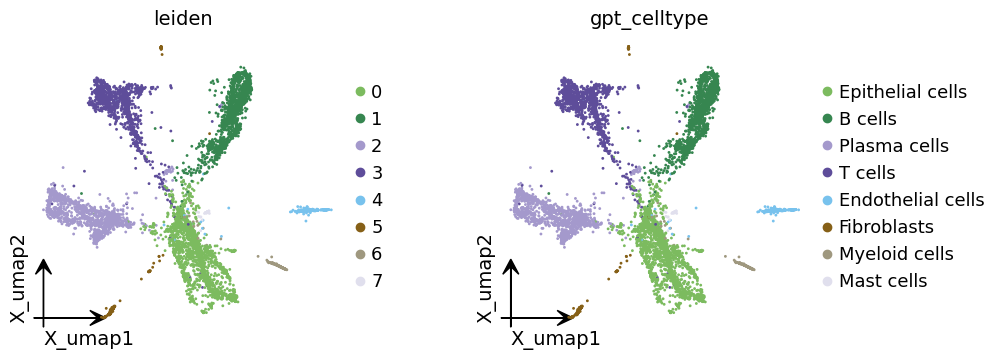

In [31]:
# 可视化查看结果
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'gpt_celltype'],
                # legend_loc='on data',
                frameon='small',
                legend_fontoutline=0.5,
                palette=ov.utils.palette()[10:],
                wspace=0.3)

In [32]:
# 统计每种细胞类型数量及占比
celltype_counts = adata.obs['gpt_celltype'].value_counts(normalize=True) * 100
print(celltype_counts)

gpt_celltype
Epithelial cells     27.219917
B cells              22.392808
Plasma cells         21.078838
T cells              18.741355
Endothelial cells     5.020747
Fibroblasts           3.153527
Myeloid cells         1.908714
Mast cells            0.484094
Name: proportion, dtype: float64


### 查看B细胞和浆细胞marker的表达情况

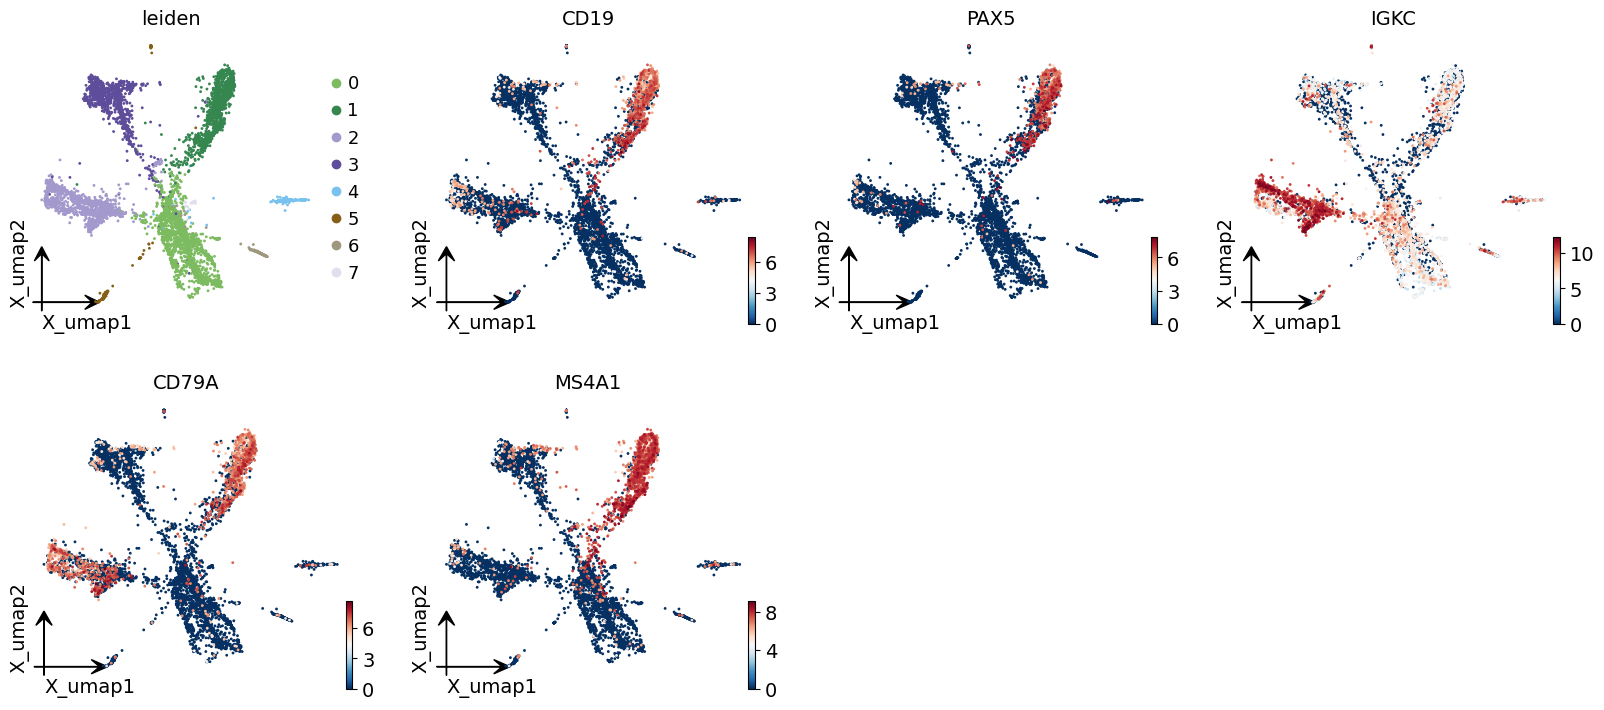

In [33]:
# B细胞marker
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'CD19', 'PAX5', 'IGKC', 'CD79A', 'MS4A1'], 
                frameon='small')

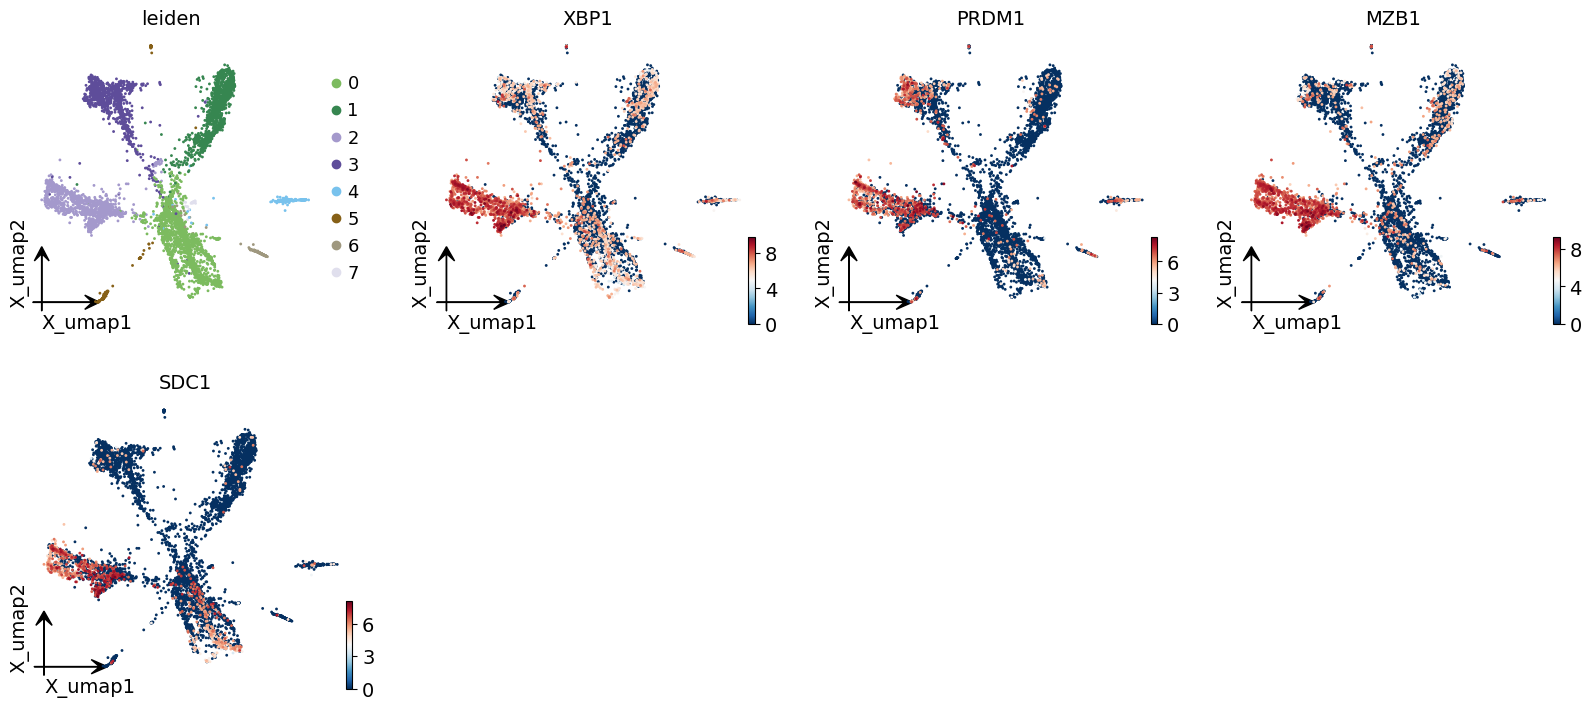

In [35]:
# 浆细胞marker
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'XBP1', 'PRDM1', 'MZB1', 'SDC1'],  # JCHAIN
                frameon='small')